# Normal Distribution in 2D

I’ve always been fascinated by the way randomness shapes patterns. One-dimensional random walks are easy to visualize, but I wanted to see how the **2D version** behaves - essentially imagining a **Galton board in two dimensions**, where each particle can move in four directions instead of falling through pins. This gives a richer, more complex picture of how probability unfolds in space.

To explore this, I simulated **thousands of independent random walks**, each consisting of a fixed number of steps. At each step, the walker can move **up, down, left, or right** with equal probability. This setup is like a tiny 2D universe where every particle starts at the origin `(0,0)` and explores its surrounding space in a completely random manner.

After all walks were completed, I recorded the **final positions of all walkers**. By counting how many walkers ended up at each coordinate, I constructed a **2D frequency grid**. In this grid, the color intensity of each point corresponds to the number of walkers that landed there.

When plotted, the resulting heatmap reveals a **diamond-shaped pattern**, which is characteristic of discrete 2D random walks. The highest density occurs at the center, reflecting the fact that most walkers do not stray far from their starting point in a small number of steps. As we move further from the origin, the likelihood of reaching those positions decreases symmetrically, forming a shape that closely resembles a **2D normal distribution** or “bell curve” in two dimensions.

An interesting observation emerges when considering the parity of the number of steps: if the number of steps is even, only squares where `(x + y) mod 2 = 0` are visited, whereas if the number of steps is odd, only squares where `(x + y) mod 2 = 1` appear in the grid.

This simple experiment provides a demonstration of how **randomness in multiple dimensions naturally produces familiar statistical patterns**. It helped me understand the randomness in more complex way and improved my probability skills.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [228]:
PATHS = 100000
PATH_LEN = 4

POSSIBLE_MOVES = np.array([
  (1, 0),
  (-1, 0),
  (0, 1),
  (0, -1)
])

In [229]:
moves = POSSIBLE_MOVES[np.random.choice(4, PATHS * PATH_LEN)]
chunked_moves = moves.reshape(PATHS, PATH_LEN, 2)
sums = chunked_moves.sum(axis = 1)

In [230]:
grid_size = 2 * PATH_LEN + 1
grid = np.zeros((grid_size, grid_size))

offset = PATH_LEN

for x, y in sums:
  grid[x + offset, y + offset] += 1

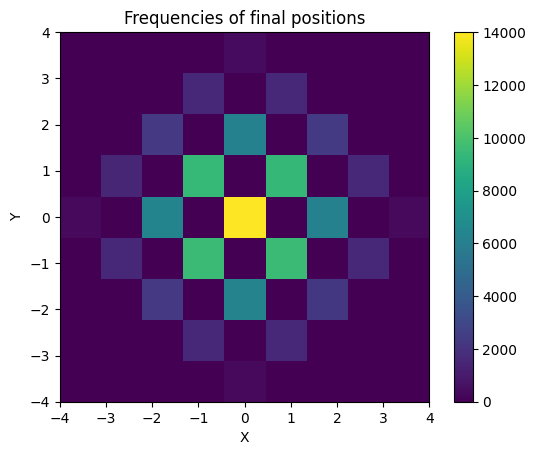

In [231]:
plt.imshow(
  grid.T,
  origin='lower',
  extent=(-PATH_LEN, PATH_LEN, -PATH_LEN, PATH_LEN)
)

plt.colorbar()
plt.title("Frequencies of final positions")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()